# Usage | 5. Data imports for city definition
This notebook explains how custom data sets can be imported into GrowBikeNet to define custom city properties, adapting to a local situation and growing more realistically.

**Parameters covered**: `import_files['growable_network'], import_files['bike_network'], import_files['seed_points'], import_files['city_boundary']`

We start every Usage notebook with the standard way of importing GrowBikeNet:

In [26]:
import growbikenet as gbn

## Save and import growable network

Here we work with Athens. When running GrowBikeNet, it uses OSMnx to fetch street network data from [OSM](https://www.openstreetmap.org/) to be used as the network on which to grow a bicycle network - the growable network. OSMnx has data caching implemented, so when running it multiple times on the same city, it will load the cached json data. Unfortunately, loading json is slow. To speed up this process, we can first download and save the undirected, driveable street network locally, under `Athens_growable_network.gpkg`, so we can load that file fast into GrowBikeNet whenever we will use it (because gpkg files are loaded fast), and use it as our growable network on which GrowBikeNet can grow its links:

In [27]:
import networkx as nx
import osmnx as ox

g = ox.graph_from_place("Municipality of Athens", network_type='drive')
g = nx.MultiGraph(ox.convert.to_digraph(g))
ox.io.save_graph_geopackage(g, "Athens_street_network.gpkg")

Now, we can use this local street network file with the `"growable_network"` key inside the `import_files` dictionary parameter:

In [28]:
edges_ordered = gbn.growbikenet("Municipality of Athens",
    import_files={"growable_network":"Athens_street_network.gpkg"},)

RUNNING GROWBIKENET FOR CITY: Municipality of Athens
betweenness | auto | from scratch
----------------------------------------------╮


Importing network data :   0%|                | 0/1 [00:00<?, ?network/s]

Creating seed points   :   0%|                | 0/3 [00:00<?, ?step/s]

Triangulation          :   0%|                | 0/1 [00:00<?, ?step/s]

Routing                :   0%|                | 0/3 [00:00<?, ?step/s]

Computing edge metrics :   0%|                | 0/2 [00:00<?, ?step/s]

Rerouting              :   0%|                | 0/28 [00:00<?, ?edge/s]

Removing edge overlaps :   0%|                | 0/28 [00:00<?, ?edge/s]

Exporting data         :   0%|                | 0/1 [00:00<?, ?file/s]

----------------------------------------------╯
Data exported to ./results/
----------------------------------------------
FINISHED IN 0:00:02


This way, the street network file can also come from any other data provider than OSM, given that the data is in the same format, or it can be modified.

### Limiting the street network definition

It could be possible that the city decides it will build protected bicycle infrastructure only on certain streets. Here we assume these are only the primary and secondary roads, implemented with a [custom filter](https://github.com/gboeing/osmnx-examples/blob/main/notebooks/08-custom-filters-infrastructure.ipynb):

In [29]:
custom_filter_streets = ['["highway"~"primary"]',
                         '["highway"~"secondary"]']

In [30]:
g_limited = ox.graph_from_place(
    "Municipality of Athens",
    custom_filter=custom_filter_streets,
    retain_all=False, # fetch only the largest connected component
)
g_limited = nx.MultiGraph(ox.convert.to_digraph(g_limited))
ox.io.save_graph_geopackage(g_limited, "Athens_street_network_limited.gpkg")

This limitation selects a much smaller subnetwork (red) of the whole street network (white):

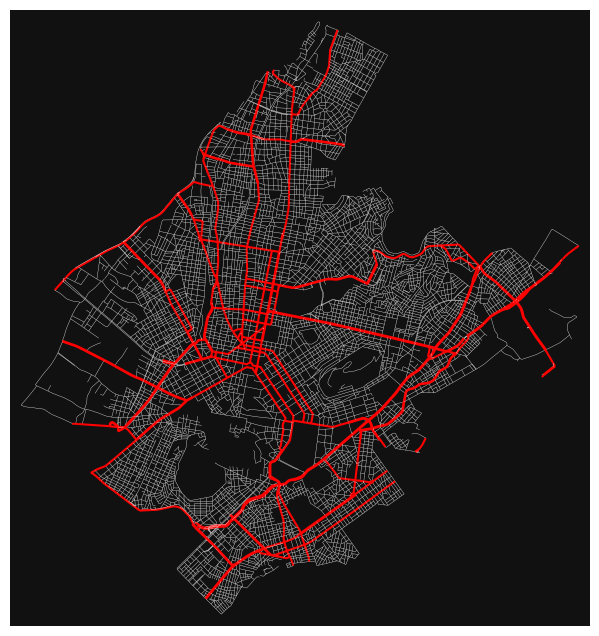

In [31]:
ec = ["r" if data["highway"] == "primary" or data["highway"] == "secondary" else "w" for u, v, key, data in g.edges(keys=True, data=True)]
el = [1.5 if data["highway"] == "primary" or data["highway"] == "secondary" else 0.25 for u, v, key, data in g.edges(keys=True, data=True)]
ox.plot_graph(g, node_size=0, edge_linewidth=el, edge_color=ec);

Because this limited network is so sparse, we need to set the snap distance for seed points to a high value before running GrowBikeNet - otherwise the resulting network will be disconnected and highly incomplete (see more details on how to use the settings in <a href="usage_06_settings_and_constants.ipynb">Usage notebook 6</a>):

In [32]:
gbn.settings.seed_point_snap_distance = 1500

In [33]:
edges_ordered_limited = gbn.growbikenet(
    "Municipality of Athens",
    import_files={"growable_network":"Athens_street_network_limited.gpkg"},
)

RUNNING GROWBIKENET FOR CITY: Municipality of Athens
betweenness | auto | from scratch
----------------------------------------------╮


Importing network data :   0%|                | 0/1 [00:00<?, ?network/s]

Creating seed points   :   0%|                | 0/3 [00:00<?, ?step/s]

Quadrangulation        :   0%|                | 0/1 [00:00<?, ?step/s]

Routing                :   0%|                | 0/3 [00:00<?, ?step/s]

Computing edge metrics :   0%|                | 0/2 [00:00<?, ?step/s]

Rerouting              :   0%|                | 0/63 [00:00<?, ?edge/s]

Removing edge overlaps :   0%|                | 0/63 [00:00<?, ?edge/s]

Exporting data         :   0%|                | 0/1 [00:00<?, ?file/s]

----------------------------------------------╯
Data exported to ./results/
----------------------------------------------
FINISHED IN 0:00:00


Let's reset the snap distance to `'auto'` now:

In [34]:
gbn.settings.seed_point_snap_distance = 'auto'

Due to the limited street network, the resulting bicycle network is also much sparser (green) than the network grown on the full street network (orange):

In [35]:
import folium

viz = edges_ordered.explore(
    tiles="CartoDB Positron",
    style_kwds={"weight": 6, "color": "#f19730"},
    name="Grown bike network (on full street network)",
)
viz = edges_ordered_limited.iloc[1:].explore(
    m=viz, 
    style_kwds={"weight": 3, "color": "#096a51"},
    name="Grown bike network (on limited street network)",
)
folium.LayerControl().add_to(viz)
viz

/Users/mszell/Github/BikeNetKit/GrowBikeNet/.pixi/envs/default/lib/python3.14/site-packages/geopandas/explore.py:388: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(scale_factor="{r}")


### The growable network should be more than the driveable streets

Note that limiting the growable network to driveable streets only, as done above with the `graph_from_place(.. network_type='drive')` download, can be wrong for a city that wants to consider elements other then driveable streets to grow its bicycle network, such as on wide foot paths. Also, using only the driveable street network as growable network does not allow GrowBikeNet to extend its existing bicycle network correctly for technical reasons.

For such reasons, when using GrowBikeNet without `import_files={"growable_network":..`, it downloads as its growable network a combination of both driveable and bikeable infrastructure elements, which is encoded in `gbn.constants.GROWABLE_NETWORK_CUSTOM_FILTER`. If you want to recreate this in your local import, you can run the following code:

In [36]:
g = ox.graph_from_place("Municipality of Athens", 
    custom_filter=gbn.constants.GROWABLE_NETWORK_CUSTOM_FILTER)
g = nx.MultiGraph(ox.convert.to_digraph(g))
ox.io.save_graph_geopackage(g, "Athens_growable_network.gpkg")

## Save and import bike network

Analogously, an existing bike network can be downloaded, saved, and imported. The download requires a custom filter for protected bicycle infrastructre (PBI) which is already provided in `gbn.constants.PBI_CUSTOM_FILTER`:

In [37]:
g = ox.graph_from_place(
    "Municipality of Athens",
    custom_filter=gbn.constants.PBI_CUSTOM_FILTER,
    retain_all=True, # fetch all connected components
)
g = nx.MultiGraph(ox.convert.to_digraph(g))
ox.io.save_graph_geopackage(g, "Athens_bike_network.gpkg")

Now it can be imported with the `"bike_network"` key inside the `import_files` dictionary parameter:

In [38]:
edges_ordered = gbn.growbikenet(
    "Municipality of Athens",
    existing_network_spacing='auto',
    seed_point_linking ='triangulate_delaunay',
    import_files={
        "growable_network":"Athens_growable_network.gpkg",
        "bike_network":"Athens_bike_network.gpkg",
    },
)

RUNNING GROWBIKENET FOR CITY: Municipality of Athens
betweenness | auto | from existing bike network 
----------------------------------------------╮


Importing network data :   0%|                | 0/2 [00:00<?, ?network/s]

Creating seed points   :   0%|                | 0/4 [00:00<?, ?step/s]

Triangulation          :   0%|                | 0/1 [00:00<?, ?step/s]

Routing                :   0%|                | 0/3 [00:00<?, ?step/s]

Computing edge metrics :   0%|                | 0/2 [00:00<?, ?step/s]

Rerouting              :   0%|                | 0/57 [00:00<?, ?edge/s]

Removing edge overlaps :   0%|                | 0/58 [00:00<?, ?edge/s]

Exporting data         :   0%|                | 0/1 [00:00<?, ?file/s]

----------------------------------------------╯
Data exported to ./results/
----------------------------------------------
FINISHED IN 0:00:03


In [39]:
import folium

viz = edges_ordered.iloc[:1].explore(
    tiles="CartoDB Positron",
    style_kwds={"weight": 2, "color": "#9999cc"},
    name="Existing bike network",
)
viz = edges_ordered.iloc[1:].explore(
    m=viz, 
    style_kwds={"weight": 3, "color": "#096a51"},
    name="Grown bike network",
)
folium.LayerControl().add_to(viz)
viz

/Users/mszell/Github/BikeNetKit/GrowBikeNet/.pixi/envs/default/lib/python3.14/site-packages/geopandas/explore.py:388: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(scale_factor="{r}")


### Relaxing the bike network definition

The import of a custom bike network is useful to change the definition of the bike network. For example, the definition could be relaxed to also consider primary streets as protected bike infrastructure, assuming that the city plans to implement protected bike lanes along all primary streets:

In [40]:
custom_filter_relaxed = gbn.constants.PBI_CUSTOM_FILTER + ['["highway"~"primary"]']

In [41]:
g = ox.graph_from_place(
    "Municipality of Athens",
    custom_filter=custom_filter_relaxed,
    retain_all=True, #fetch all connected components
)
g = nx.MultiGraph(ox.convert.to_digraph(g))
ox.io.save_graph_geopackage(g, "Athens_bike_network_relaxed.gpkg")

In [42]:
edges_ordered_relaxed = gbn.growbikenet(
    "Municipality of Athens",
    existing_network_spacing='auto',
    seed_point_linking='triangulate_delaunay',
    import_files={
        "growable_network":"Athens_growable_network.gpkg",
        "bike_network":"Athens_bike_network_relaxed.gpkg"
    },
)

RUNNING GROWBIKENET FOR CITY: Municipality of Athens
betweenness | auto | from existing bike network 
----------------------------------------------╮


Importing network data :   0%|                | 0/2 [00:00<?, ?network/s]

Creating seed points   :   0%|                | 0/4 [00:00<?, ?step/s]

Triangulation          :   0%|                | 0/1 [00:00<?, ?step/s]

Routing                :   0%|                | 0/3 [00:00<?, ?step/s]

Computing edge metrics :   0%|                | 0/2 [00:00<?, ?step/s]

Rerouting              :   0%|                | 0/76 [00:00<?, ?edge/s]

Removing edge overlaps :   0%|                | 0/77 [00:00<?, ?edge/s]

Exporting data         :   0%|                | 0/1 [00:00<?, ?file/s]

----------------------------------------------╯
Data exported to ./results/
----------------------------------------------
FINISHED IN 0:00:04


This creates a different looking bicycle network:

In [43]:
viz = edges_ordered_relaxed.iloc[:1].explore(
    tiles="CartoDB Positron",
    style_kwds={"weight": 2, "color": "#9999cc"},
    name="Existing bike network (relaxed)",
)
viz = edges_ordered_relaxed.iloc[1:].explore(
    m=viz, 
    style_kwds={"weight": 3, "color": "#096a51"},
    name="Grown bike network",
)
folium.LayerControl().add_to(viz)
viz

/Users/mszell/Github/BikeNetKit/GrowBikeNet/.pixi/envs/default/lib/python3.14/site-packages/geopandas/explore.py:388: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(scale_factor="{r}")


## Import seed points

[Usage notebook 1](usage_01_seed_points.ipynb#custom-seed-points) explains how to import custom seed points. 

## Import city boundary

When GrowBikeNet runs, it automatically finds the city boundary on OSM via OSMnx's `graph_from_place()` function from the given `city_query`. However, sometimes the desired city boundary does not exist on OSM. In Copenhagen, for example, OSMnx returns a multipolygon consisting of several polygons -two big and some small islands-, where also one of the big polygons has a hole inside (which is Frederiksberg municipality). This is demonstrated using OSMnx's `geocode_to_gdf()` function which downloads the city boundary from a query:

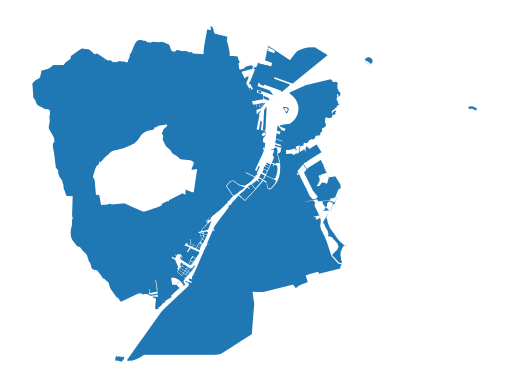

In [44]:
copenhagen_boundary = ox.geocoder.geocode_to_gdf("copenhagen municipality")
ax = copenhagen_boundary.plot()
ax.set_axis_off()

This shape is suboptimal, as it does not cover bridges nor Frederiksberg. Because of such cases, and also to provide a completely flexible framework allowing to focus on places not encoded in OSM like neighborhoods, GrowBikeNet provides a city boundary import option via the `import_files['city_boundary']` parameter\. This boundary can be a gpkg or a shape (shp) file. One is provided in GrowBikeNet's [`tests` folder](https://github.com/BikeNetKit/GrowBikeNet/tree/main/tests/test_data):

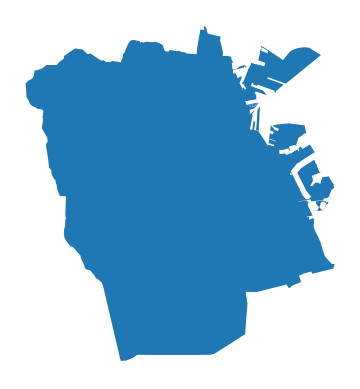

In [45]:
import geopandas as gpd

boundary_path = '../../tests/test_data/copenhagen_city_boundary.shp'
copenhagen_boundary_fixed = gpd.read_file(boundary_path)
ax = copenhagen_boundary_fixed.plot()
ax.set_axis_off()

This file can now be used to define a fixed city boundary for Copenhagen, to be used in GrowBikeNet:

In [46]:
edges_ordered = gbn.growbikenet("Copenhagen",
    import_files = {'city_boundary': boundary_path})

RUNNING GROWBIKENET FOR CITY: Copenhagen
betweenness | auto | from scratch
----------------------------------------------╮


Creating seed points   :   0%|                | 0/3 [00:00<?, ?step/s]

Triangulation          :   0%|                | 0/1 [00:00<?, ?step/s]

Routing                :   0%|                | 0/3 [00:00<?, ?step/s]

Computing edge metrics :   0%|                | 0/2 [00:00<?, ?step/s]

Rerouting              :   0%|                | 0/263 [00:00<?, ?edge/s]

Removing edge overlaps :   0%|                | 0/263 [00:00<?, ?edge/s]

Exporting data         :   0%|                | 0/1 [00:00<?, ?file/s]

----------------------------------------------╯
Data exported to ./results/
----------------------------------------------
FINISHED IN 0:00:21


We can see how the whole city is now covered, including Frederiksberg:

In [47]:
edges_ordered.explore(tiles="CartoDB Positron",
    style_kwds={"weight": 3, "color": "#096a51"})

/Users/mszell/Github/BikeNetKit/GrowBikeNet/.pixi/envs/default/lib/python3.14/site-packages/geopandas/explore.py:388: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(scale_factor="{r}")
